<a href="https://colab.research.google.com/github/vvaldiviacalvo-create/telecom-analysis/blob/main/telecom_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

users_nulos = users.isna().sum()
users_proporcion_nulos = users.isna().mean()

print("Cantidad de valores nulos:", users_nulos)
print("Proporción de valores nulos", users_proporcion_nulos)

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

usage_nulos = usage.isna().sum()
usage_proporcion_nulos = usage.isna().mean()

print("Cantidad de valores nulos:", usage_nulos)
print("Proporción de valores nulos", usage_proporcion_nulos)

Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Users: La columna city tiene un 11.72% de valores faltantes y la columna churn_date tiene una proporcion de 88.35% de valores faltantes
  Usage: La columna duration tiene un 55,19% de valores faltantes y la columna lenght tiene un 44,74%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
    Users:
    En la columna city investigar si se imputa o se deja como nulos.
    Y en la columna churn_date como la proporción de nulos es muy elevada es mejor no considerarla en el análisis, por lo que se ignora o elimina.

  Usage:
    Se debe investigar si es posible imputar ambas columnas (duration y length) de acuerdo con la lógica del negocio
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`, tiene los 4000 registros esperados, que empiezan en el valor 10000 y terminan en 13999 secuencialmente. Valores como la media y la desviación estandar no tiene valor aqui por tratarse de la columna del id de usuario
- La columna `age`, también tiene los 4000 registros esperados, sin valores nulos. La edad promedio son 33.7 años, una edad máxima de 79 años, y un outilier en la edad mínima (-999)

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan los 40000 valores esperados secuencialmente. Al tratarse de identificadores, los valores estadísticos no tienen relevancia.
- La columna duration tiene muy pocos valores registrados los cuales deben analizarse para darles un manejo adecuado. El valor mínimo es 0, posiblemente por llamadas que no conectaron o fueron llamadas perdidas, y el valor máximo 120 minutos, lo que corresponde a una llamada larga pero posible.
- La columna lenght tambien muestra pocos registros que se deben analizar para darles un trato adecuado. El valor mínimo es normal, pudo haber un mensaje de texto vacío. El valor máximo (1490) parece demasiado alto, se debe revisar si es un outlier

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene valores invalidos, existen 7 ciudades únicas en la base de datos, siendo Bogotá la que más se repite
- La columna `plan` no tiene valores nulos. Tiene dos 2 tipos de planes registrados (lo cual es concuerda con lo indicado en el data set plans). El plan más registrado es el básico, el cual aparece 2595 veces.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`, no tiene valores nulos, tiene dos valores únicos registrados (según analizamos anteriormete estos dos registros corresponden a llamadas y texto), siendo más frecuente text con 22092 registros


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  solamente en la columna city hay valores invalidos o sentinels
- ¿Qué acción tomarías?  Revisar más a fondo la columna city para imputar

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime (users['reg_date']) # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime (usage['date']) # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay valores registrados de 2022 a 2024, no hay valores para 2025 y hay 40 registros en 2026 (año en curso)

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solamente se registran fechas de 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos), Sí, hay fechas de 2026, año que se encuentra en curso
- ¿Qué harías con ellas? Al tratarse de una proporción de 40 registros sobre un total de 4000, se recomienda filtrar y eliminar estos 40 registros

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
text_sentinels = ["?"]
users['city'] = users['city'].replace(text_sentinels, pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se confirma que los valores nulos en duration y length son MAR y tienen relación directa con la columna type. Duration presenta casi un 100% de nulos cuando el registro es text, debido a que los mensajes de texto no tienen una duracion temporal. De igual forma length tiene un 100% de nulos en call porque las llamadas de voz no tienen longitud de caracteres.
De tal manera los datos se dejan como nulos, ya que imputarlos distorcionaría la realidad del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["is_duration"] = usage["duration"].fillna(0) #conocer el total de minutos de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    is_text=("is_text", "sum"),
    is_call=("is_call","sum"),
    is_duration=("is_duration","sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,is_duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call': 'cant_llamadas',
    'is_duration' : 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print('Resumen estadístico por usuario durante el 2024')
print(user_profile[columnas_numericas].describe())


Resumen estadístico por usuario durante el 2024
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True))


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

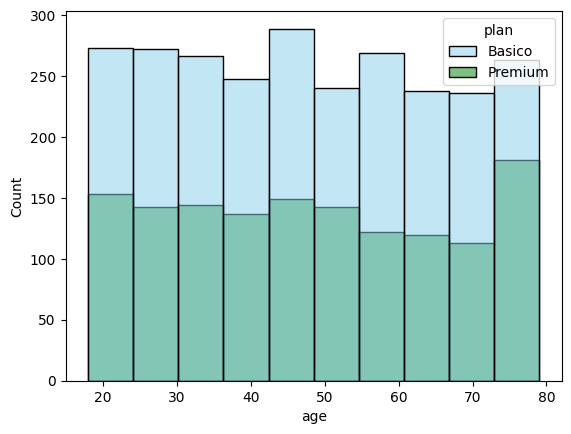

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights:
- Distribución para la variable age es uniforme (sin sesgos hacia la izquierda o la derecha), lo que muestra que el volumen de usuarios se reparte equitativamente dentro del rango de edades.
- La proporción de usuarios se mantiene relativamente constante en todos los rangos de edad, observándose un ligero incremento en el segmento de usuarios de 75 a 80 años. Por su parte, el plan Básico es consistentemente el preferido en todo el ciclo de vida de los clientes.
- No se visualiza una tendencia clara de segmentación por edad; es decir, la edad no parece ser un factor determinante o influyente al momento de elegir entre el plan Básico o Premium.

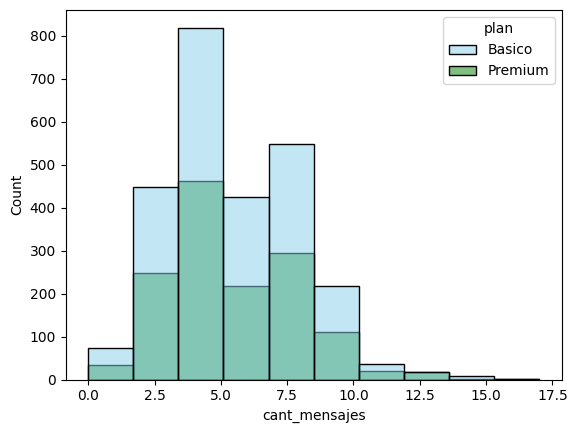

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights:

- Dentro del plan Premium y Básico, se observa una alta similitud en la proporción y el comportamiento de uso. El plan Básico mantiene barras más altas debido a su mayor cuota de usuarios generales, pero la distribución del consumo sigue el mismo ritmo en ambos segmentos.
- Los usuarios tienden a enviar un promedio bajo de mensajes, registrando un pico máximo alrededor de los 5.0 mensajes por usuario. El grueso de la población se estabiliza por debajo de los 10 mensajes, existiendo muy pocos casos de usuarios con un uso intensivo que superen los 12.5 mensajes mensuales.
- La variable presenta una distribución sesgada a la derecha. La mayor parte de la población se concentra en la zona baja/media de la escala, y la frecuencia desciende de forma paulatina a medida que aumenta la cantidad de mensajes enviados.


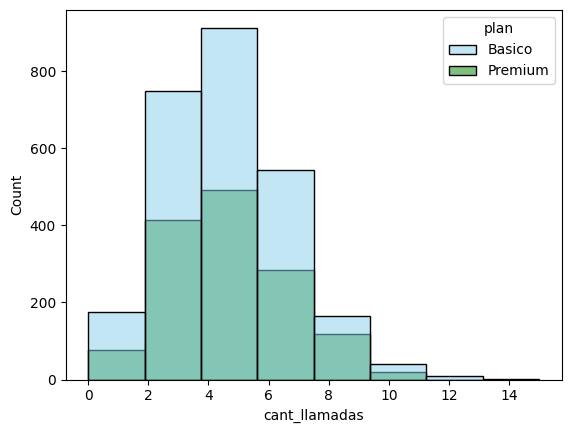

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=8, palette=['skyblue','green'])
plt.show()

💡Insights:
- Dentro del plan Premium y Básico, se observa una alta similitud en la proporción y el comportamiento de uso. El plan Básico mantiene barras más altas debido a su mayor cuota de usuarios generales, pero la distribución del consumo sigue el mismo ritmo en ambos segmentos.
- Los usuarios tienden a realizar un promedio bajo de llamadas, registrando un pico máximo alrededor de las 5.0 llamadas por usuario. El grueso de la población se estabiliza por debajo de las 10 llamadas, existiendo muy pocos casos de usuarios con un uso intensivo que superen las 10 llamadas mensuales.
- La variable presenta una distribución sesgada a la derecha. La mayor parte de la población se concentra en la zona baja/media de la escala, y la frecuencia desciende de forma paulatina a medida que aumenta la cantidad de llamadas realizadas.


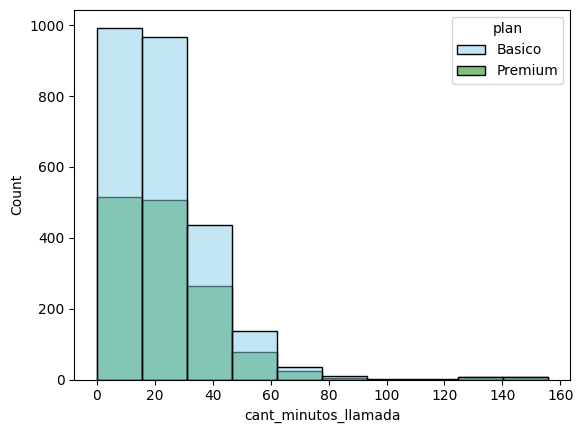

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights:
- Dentro del plan Premium y Básico, las distribuciones son prácticamente idénticas en su comportamiento de caída. Esto demuestra que el tipo de plan contratado no altera la necesidad o el hábito de consumo de minutos de voz por parte de los usuarios.
- Los usuarios tienden a hacer un uso sumamente breve del servicio de llamadas, concentrando el pico más alto de la distribución entre los 0 y 20 minutos mensuales. Es muy poco común que un cliente supere los 60 minutos totales de conversación, aunque existen ligeras excepciones en el extremo derecho que superan los 140 minutos
- La variable presenta una distribución fuertemente sesgada a la derecha con un comportamiento de descenso exponencial. La densidad de los datos disminuye drásticamente conforme aumenta la cantidad de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

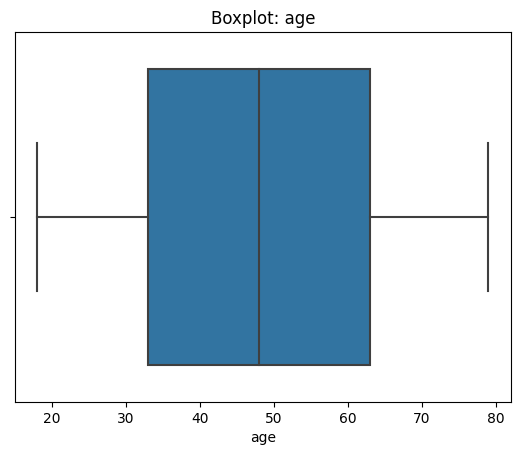

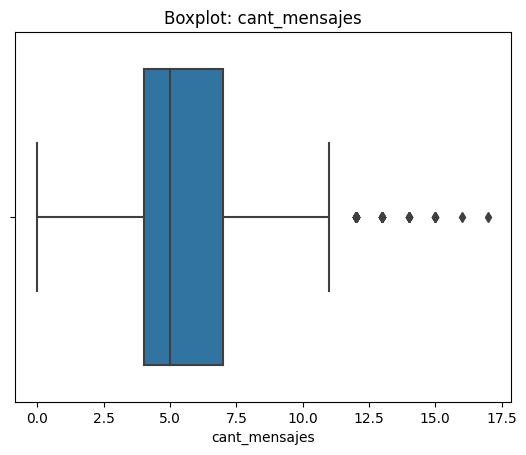

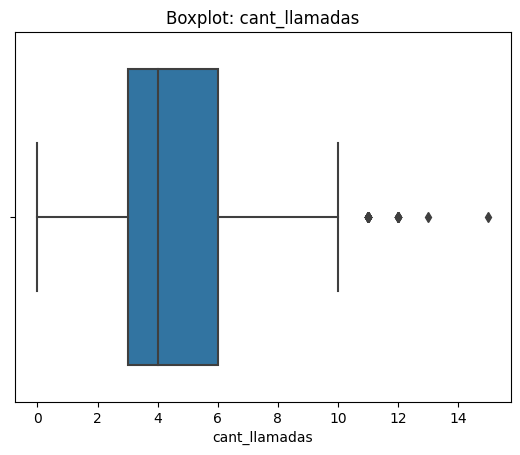

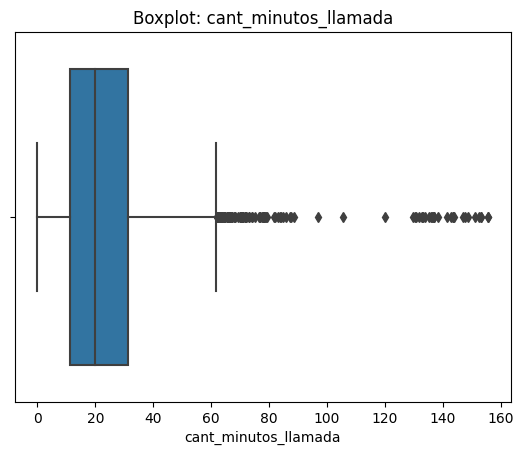

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta outliers en el limite superior
- cant_llamadas: presenta outliers en el limite superior
- cant_minutos_llamada: presenta outliers en el limite superior

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Diccionario para almacenar los límites superiores de cada variable
limites_superiores = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    limite_superior = Q3 + (1.5*IQR)
    limites_superiores[col] = limite_superior

# Mostrar los límites calculados para referencia
for col, limite in limites_superiores.items():
    print(f"Límite superior para {col}: {limite:.2f}")



Límite superior para cant_mensajes: 11.50
Límite superior para cant_llamadas: 10.50
Límite superior para cant_minutos_llamada: 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?:
  Aunque el límite superior estadístico es de 11.50 mensajes, el valor máximo real alcanza los 17 mensajes. Se deben mantener porque un consumo de 17 mensajes al mes es completamente factible para un usuario real; eliminar estos datos subestimaría la actividad de mensajería en los planes.
  
- cant_llamadas: mantener o no outliers, porqué?: El límite calculado es de 10.50 llamadas, pero tenemos registros legítimos de hasta 15 llamadas en el mes. No representan un error de sistema ni de captura, sino que reflejan el comportamiento de un grupo de clientes altamente activos que es vital conservar para dimensionar correctamente el uso de la red telefónica.

- cant_minutos_llamada: mantener o no outliers, porqué?: Esta variable presenta la diferencia más extrema, donde el límite es de 61.86 minutos pero el máximo llega hasta los 155.69 minutos. Es indispensable mantenerlos porque en la industria de telecomunicaciones, los "usuarios pesados" (heavy users) que pasan más de dos horas al mes hablando representan un segmento comercial de alto valor que define la demanda máxima de infraestructura.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_usuario_grupo(fila):
    # Condición 1: Bajo uso
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'

    # Condición 2: Uso medio
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'

    # Condición 3: El resto de los casos
    else:
        return 'Alto uso'

# 2. Aplicar la función
user_profile['grupo_uso'] = user_profile.apply(clasificar_usuario_grupo, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_usuario_edad(fila):
    # Condición 1: Joven
    if fila['age'] < 30:
        return 'Joven'

    # Condición 2: Adulto
    elif fila['age'] < 60:
        return 'Adulto'

    # Condición 3: Adulto mayor
    else:
        return 'Adulto mayor'

# 2. Aplicar la función
user_profile['grupo_edad'] = user_profile.apply(clasificar_usuario_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

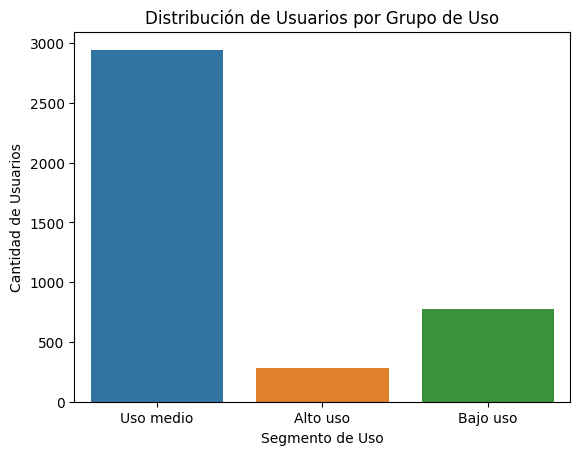

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

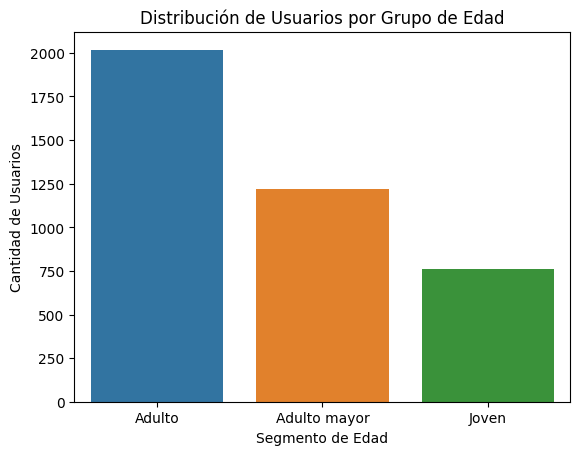

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
    En el data set users la columna City tenía un 11.72% de valores faltantes y la columna churn_date tenía una proporcion de 88.35% de valores faltantes. En el data ser Usage la columna duration tenía un 55,19% de valores faltantes y la en la columna length falta un 44,74% de valores.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

  Segmentación por Edad: Los usuarios presentan una distribución uniforme según su edad (repartida equitativamente entre los 18 y los 80 años). La edad no es un factor determinante para la elección del plan, ya que las proporciones de contratación de los planes Basico y Premium se mantienen paralelas en casi todas las edades (con un ligero repunte del plan Premium en adultos mayores de 75 a 80 años).

Segmentación por Uso: Identificamos tres grupos claros: Bajo uso (usuarios que consumen < 5 mensajes y llamadas), Uso medio (< 10) y Alto uso (el resto). El grueso de los clientes se estanca rápidamente en niveles bajos o medios de consumo: la mayoría envía entre 3.5 y 5.0 mensajes, realiza entre 4.0 y 6.0 llamadas y consume menos de 15 minutos de voz al mes, independientemente de pagar un plan Básico o Premium.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

  El segmento más valioso en términos de margen de ganancia son los usuarios del Plan Premium en los niveles de Bajo y Medio Uso. El análisis demostró que las curvas de consumo de minutos, mensajes y llamadas para el plan Premium son casi idénticas a las del plan Basico. Esto significa que ConnectaTel tiene una gran cantidad de clientes cobrando una tarifa Premium alta, pero que en realidad consumen muy pocos recursos reales de infraestructura y red telefónica (un comportamiento altamente rentable).
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Los hallazgos: El cálculo con el método IQR identificó outliers en las tres métricas: usuarios que envían hasta 17 mensajes (límite 11.5), realizan hasta 15 llamadas (límite 10.5) y consumen hasta 155.69 minutos de voz (límite teórico 61.86). Estos usuarios extremos no son errores; representan a los "Heavy Users" (usuarios pesados o corporativos). Mantenerlos en el análisis es vital porque ellos definen los picos de demanda máxima que la infraestructura de ConnectaTel debe soportar para no saturarse, y son los clientes con mayor riesgo de fuga (churn) si se les aplican cargos por excedentes de forma muy estricta.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

  Lanzamiento de un "Plan Micro / Conectado": Debido a que el consumo generalizado de minutos es sumamente bajo (0 a 15 minutos mensuales para la gran mayoría), ConnectaTel podría capturar un mercado masivo lanzando un plan económico enfocado puramente en datos/internet que reduzca al mínimo los minutos de voz incluidos.

Fidelización del segmento de Adultos Mayores: Dado que se detectó un aumento de adopción voluntaria del plan Premium entre los 75 y 80 años, se recomienda estructurar campañas de marketing directo enfocadas en este grupo demográfico.

Monetización de los Heavy Users: Para los usuarios que rompen las barreras de los 60 minutos de llamadas, crear un paquete de add-ons o extensiones ilimitadas de minutos que puedan comprar directamente desde una app para mitigar la fricción de consumo sin obligarlos a saltar a un plan corporativo completo.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el data set users la columna City tenía un 11.72% de valores faltantes y la columna churn_date tenía una proporcion de 88.35% de valores faltantes.
- En el data ser Usage la columna duration tenía un 55,19% de valores faltantes y la en la columna length falta un 44,74% de valores.


🔍 **Segmentos por Edad**
- Los usuarios presentan una distribución uniforme según su edad (repartida equitativamente entre los 18 y los 80 años).
-  La edad no es un factor determinante para la elección del plan, ya que las proporciones de contratación de los planes Basico y Premium se mantienen paralelas en casi todas las edades (con un ligero repunte del plan Premium en adultos mayores de 75 a 80 años).


📊 **Segmentos por Nivel de Uso**
- Bajo uso (usuarios que consumen < 5 mensajes y llamadas), Uso medio (< 10) y Alto uso (el resto).
- El grueso de los clientes se estanca rápidamente en niveles bajos o medios de consumo: la mayoría envía entre 3.5 y 5.0 mensajes, realiza entre 4.0 y 6.0 llamadas y consume menos de 15 minutos de voz al mes, independientemente de pagar un plan Básico o Premium.


➡️ Esto sugiere que el segmento más valioso en términos de margen de ganancia son los usuarios del Plan Premium en los niveles de Bajo y Medio Uso. El análisis demostró que las curvas de consumo de minutos, mensajes y llamadas para el plan Premium son casi idénticas a las del plan Basico. Esto significa que ConnectaTel tiene una gran cantidad de clientes cobrando una tarifa Premium alta, pero que en realidad consumen muy pocos recursos reales de infraestructura y red telefónica (un comportamiento altamente rentable)


💡 **Recomendaciones**
- Lanzamiento de un "Plan Micro / Conectado": Debido a que el consumo generalizado de minutos es sumamente bajo (0 a 15 minutos mensuales para la gran mayoría), ConnectaTel podría capturar un mercado masivo lanzando un plan económico enfocado puramente en datos/internet que reduzca al mínimo los minutos de voz incluidos.
- Fidelización del segmento de Adultos Mayores: Dado que se detectó un aumento de adopción voluntaria del plan Premium entre los 75 y 80 años, se recomienda estructurar campañas de marketing directo enfocadas en este grupo demográfico.
- Monetización de los Heavy Users: Para los usuarios que rompen las barreras de los 60 minutos de llamadas, crear un paquete de add-ons o extensiones ilimitadas de minutos que puedan comprar directamente desde una app para mitigar la fricción de consumo sin obligarlos a saltar a un plan corporativo completo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`